In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Sample - Superstore.csv",encoding='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print(df.shape)

(9994, 21)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
print("Nombre de doublons:",df.duplicated().sum())

Nombre de doublons: 0


In [8]:
df['Order Date']=pd.to_datetime(df['Order Date'],format='%m/%d/%Y')

In [9]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')


In [10]:
df[['Order Date','Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [11]:
df['Order Year']=df['Order Date'].dt.year

In [12]:
df['Order Month']=df['Order Date'].dt.month

In [13]:
df['Delivery Time']=(df['Ship Date']- df['Order Date']).dt.days

In [14]:
df[['Order Date','Ship Date','Delivery Time']].head()

,Order Date,Ship Date,Delivery Time
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [15]:
print("Sales negatives:",(df['Sales']<=0).sum())
print("quantity negatives",(df['Quantity']<0).sum())
print("delivery time negative (livree avant commande?):",(df['Delivery Time']<0).sum())

Sales negatives: 0
quantity negatives 0
delivery time negative (livree avant commande?): 0


In [16]:
q1=df['Sales'].quantile(0.25)

In [17]:
q3=df['Sales'].quantile(0.75)

In [18]:
iqr=q3-q1

In [19]:
borne_inf=q1-1.5*iqr
borne_sup=q3+1.5*iqr

In [20]:
outliers=df[(df['Sales']<borne_inf)|(df['Sales']>borne_sup)]
print(f"nombre d'outiliers sur sales:{len(outliers)}({len(outliers)/len(df)*100:.1f}%)")

nombre d'outiliers sur sales:1167(11.7%)


In [21]:
import matplotlib.pyplot as plt

In [22]:
import seaborn as sns

In [23]:
sns.set_style("whitegrid")

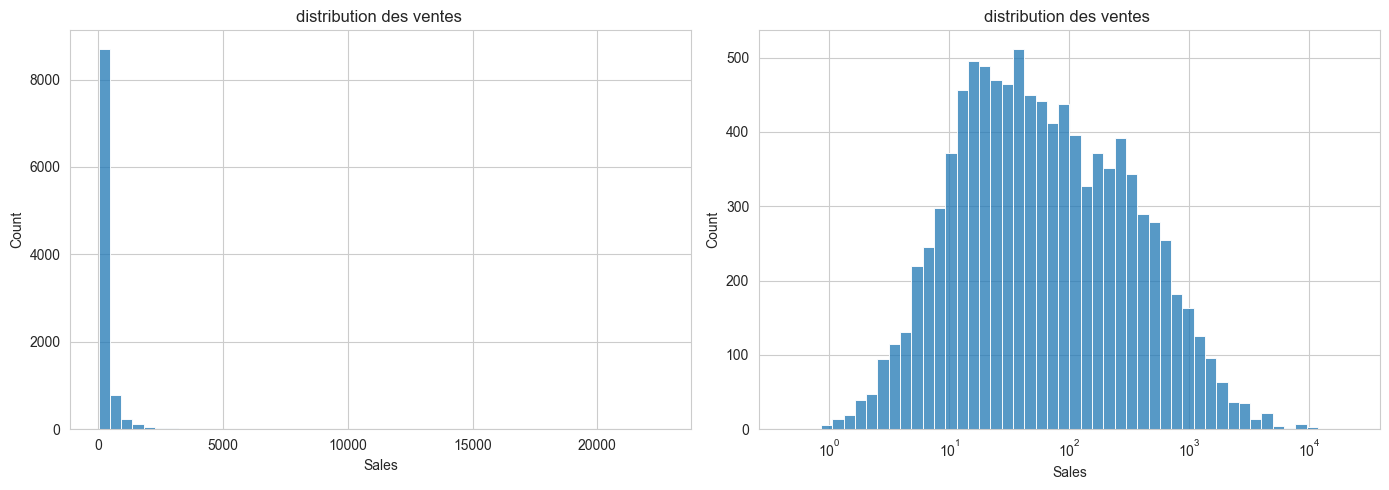

In [24]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.histplot(df['Sales'],bins=50,ax=axes[0])
axes[0].set_title("distribution des ventes ")
sns.histplot(df['Sales'],bins=50,ax=axes[1],log_scale=True)
axes[1].set_title("distribution des ventes ")
plt.tight_layout()
plt.show()

In [25]:
cat_stats=df.groupby('Category')[['Sales','Profit']].sum().sort_values('Sales',ascending=False)
print(cat_stats)

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


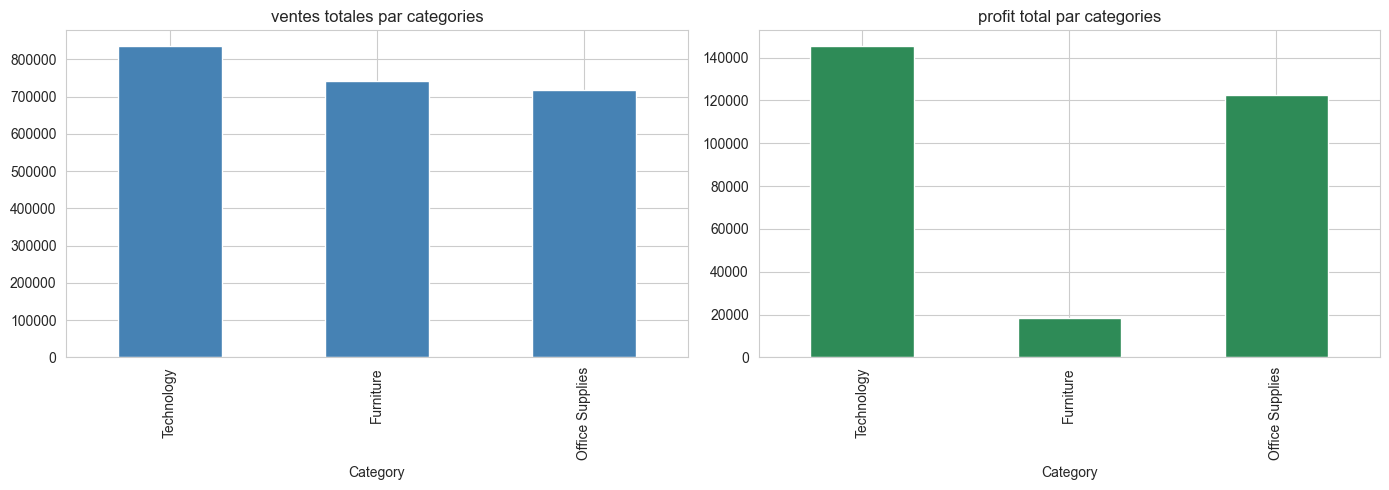

In [26]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
cat_stats['Sales'].plot(kind='bar',ax=axes[0],color='steelblue',title="ventes totales par categories")
cat_stats['Profit'].plot(kind='bar',ax=axes[1],color='seagreen',title="profit total par categories")
plt.tight_layout()
plt.show()

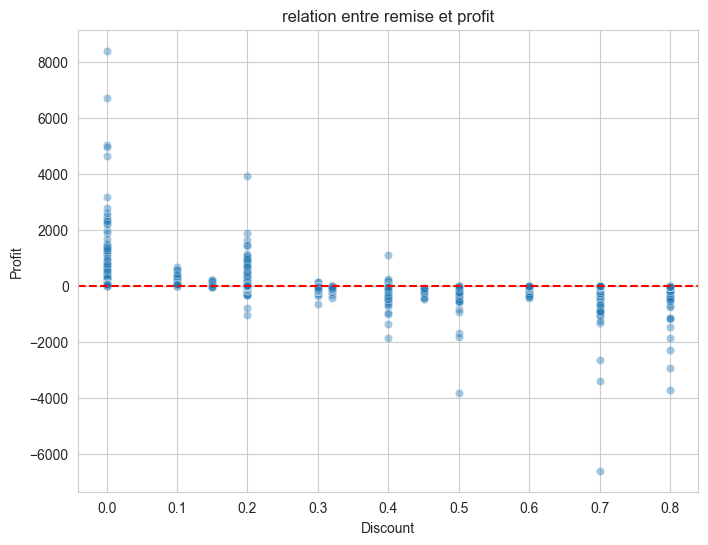

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='Discount',y='Profit',alpha=0.4)
plt.axhline(0,color='red',linestyle='--')
plt.title("relation entre remise et profit")
plt.show()

C:\Users\ayach\AppData\Local\Temp\ipykernel_3472\3993726440.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Discount_bin')['Profit'].mean().plot(kind='bar',color='coral',title="profit moyen par trnache de remise")


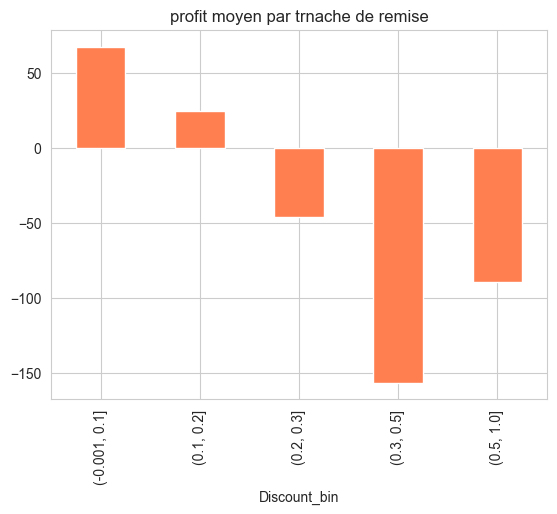

In [28]:
df['Discount_bin']=pd.cut(df['Discount'],bins=[0,0.1,0.2,0.3,0.5,1],include_lowest=True)
df.groupby('Discount_bin')['Profit'].mean().plot(kind='bar',color='coral',title="profit moyen par trnache de remise")
plt.show()

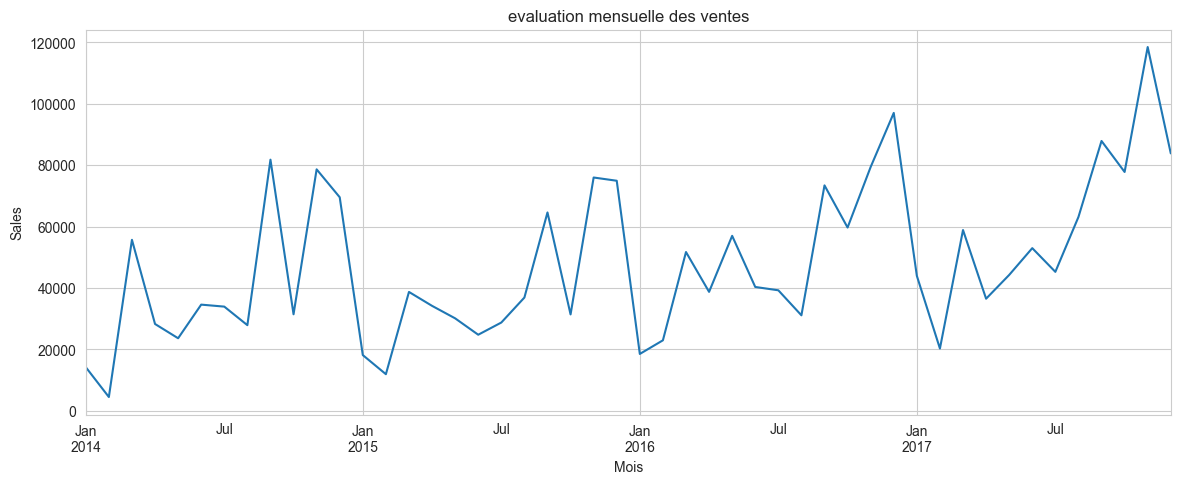

In [29]:
monthly_sales=df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
plt.figure(figsize=(14,5))
monthly_sales.plot()
plt.title("evaluation mensuelle des ventes")
plt.ylabel("Sales")
plt.xlabel("Mois")
plt.show()

In [30]:
df.groupby('Discount_bin')['Profit'].agg(['mean','count'])

C:\Users\ayach\AppData\Local\Temp\ipykernel_3472\224489967.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Discount_bin')['Profit'].agg(['mean','count'])


,mean,count
Discount_bin,,
"(-0.001, 0.1]",67.460503,4892
"(0.1, 0.2]",24.738824,3709
"(0.2, 0.3]",-45.679636,227
"(0.3, 0.5]",-156.282991,310
"(0.5, 1.0]",-89.438144,856


In [31]:
num_cols=['Sales','Quantity','Discount','Profit','Delivery Time']
corr_matrix=df[num_cols].corr()
print(corr_matrix)

                  Sales  Quantity  Discount    Profit  Delivery Time
Sales          1.000000  0.200795 -0.028190  0.479064      -0.007354
Quantity       0.200795  1.000000  0.008623  0.066253       0.018298
Discount      -0.028190  0.008623  1.000000 -0.219487       0.000408
Profit         0.479064  0.066253 -0.219487  1.000000      -0.004649
Delivery Time -0.007354  0.018298  0.000408 -0.004649       1.000000


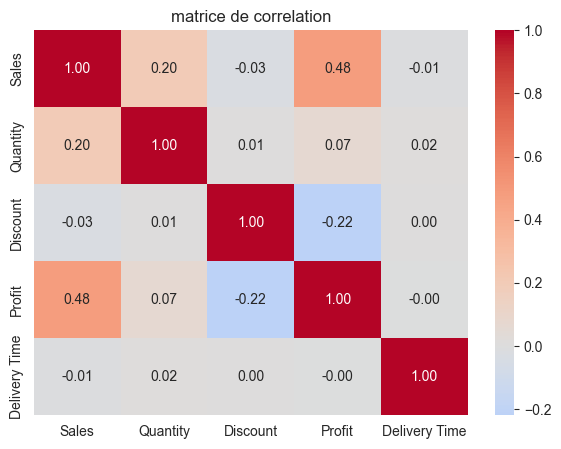

In [32]:
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',center=0,fmt='.2f')
plt.title("matrice de correlation")
plt.show()

In [33]:
from scipy import stats

In [34]:
low_discount=df[df['Discount']<=0.1]['Profit']
high_discount=df[df['Discount']>0.3]['Profit']

In [35]:
t_stat,p_value=stats.ttest_ind(low_discount,high_discount,equal_var=False)
print(f"t-statistic:{t_stat:.2f},p-value:{p_value:.5f}")

t-statistic:15.82,p-value:0.00000


In [36]:
df['Is_profitable']=(df['Profit']>0).astype(int)

In [37]:
print(df['Is_profitable'].value_counts())

Is_profitable
1    8058
0    1936
Name: count, dtype: int64


In [38]:
print(df['Is_profitable'].value_counts(normalize=True) * 100)

Is_profitable
1    80.628377
0    19.371623
Name: proportion, dtype: float64


In [39]:
features=['Category','Sub-Category','Region','Segment',
          'Discount','Quantity','Ship Mode','Sales']


In [40]:
X=df[features].copy()
y=df['Is_profitable']

In [41]:
X=pd.get_dummies(X,columns=['Category','Sub-Category','Region','Segment','Ship Mode'],drop_first=True)

In [42]:
print(X.shape)

(9994, 29)


In [43]:
X.head()

,Discount,Quantity,Sales,Category_Office Supplies,Category_Technology,Sub-Category_Appliances,Sub-Category_Art,Sub-Category_Binders,Sub-Category_Bookcases,Sub-Category_Chairs,...,Sub-Category_Supplies,Sub-Category_Tables,Region_East,Region_South,Region_West,Segment_Corporate,Segment_Home Office,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,0.00,2,261.9600,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
1,0.00,3,731.9400,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,True,False
2,0.00,2,14.6200,True,False,False,False,False,False,False,...,False,False,False,False,True,True,False,False,True,False
3,0.45,5,957.5775,False,False,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
4,0.20,2,22.3680,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

In [46]:
print("train:",X_train.shape,"test:",X_test.shape)

train: (7995, 29) test: (1999, 29)


In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [50]:
log_reg=LogisticRegression(max_iter=1000,random_state=42)
log_reg.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [51]:
y_pred_log=log_reg.predict(X_test_scaled)

In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
rf=RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42,class_weight='balanced')
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [54]:
y_pred_rf=rf.predict(X_test)

In [55]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score


==================================================\Logistic Regression
accuracy: 0.9424712356178089

 Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.79      0.84       387
           1       0.95      0.98      0.96      1612

    accuracy                           0.94      1999
   macro avg       0.93      0.88      0.90      1999
weighted avg       0.94      0.94      0.94      1999



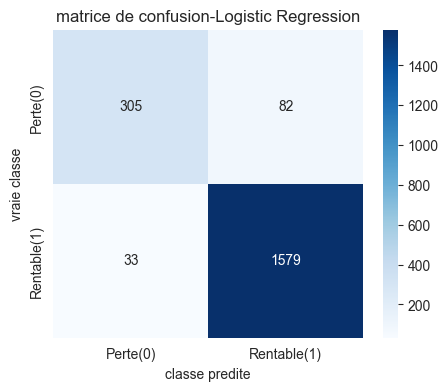


==================================================\Random Forest
accuracy: 0.9339669834917459

 Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.89      0.84       387
           1       0.97      0.94      0.96      1612

    accuracy                           0.93      1999
   macro avg       0.88      0.92      0.90      1999
weighted avg       0.94      0.93      0.94      1999



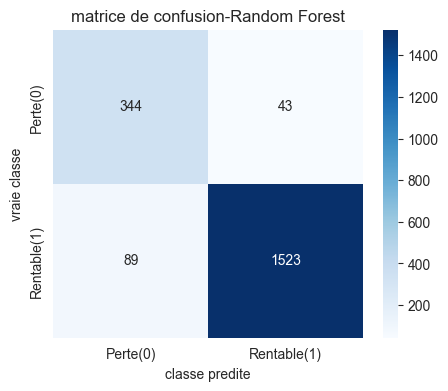

In [56]:
for name,y_pred in[("Logistic Regression",y_pred_log),("Random Forest",y_pred_rf)]:
    print(f"\n{'='*50}\{name}\n{'='*50}")
    print("accuracy:",accuracy_score(y_test,y_pred))
    print("\n Classification Report:\n",classification_report(y_test,y_pred))
    cm=confusion_matrix(y_test,y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
               xticklabels=['Perte(0)','Rentable(1)'],
               yticklabels=['Perte(0)','Rentable(1)'])
    plt.ylabel('vraie classe')
    plt.xlabel('classe predite')
    plt.title(f'matrice de confusion-{name}')
    plt.show()

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score

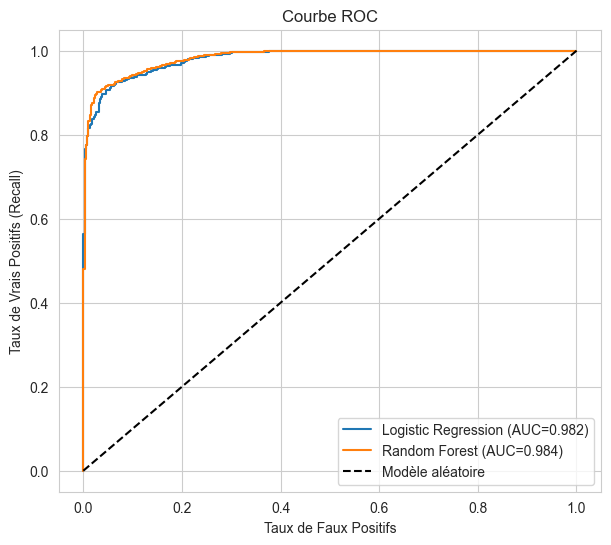

In [58]:
y_proba_log = log_reg.predict_proba(X_test_scaled)[:,1]
y_proba_rf = rf.predict_proba(X_test)[:,1]

plt.figure(figsize=(7,6))
for name, y_proba in [("Logistic Regression", y_proba_log), ("Random Forest", y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--', label="Modèle aléatoire")
plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs (Recall)")
plt.title("Courbe ROC")
plt.legend()
plt.show()

In [59]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)


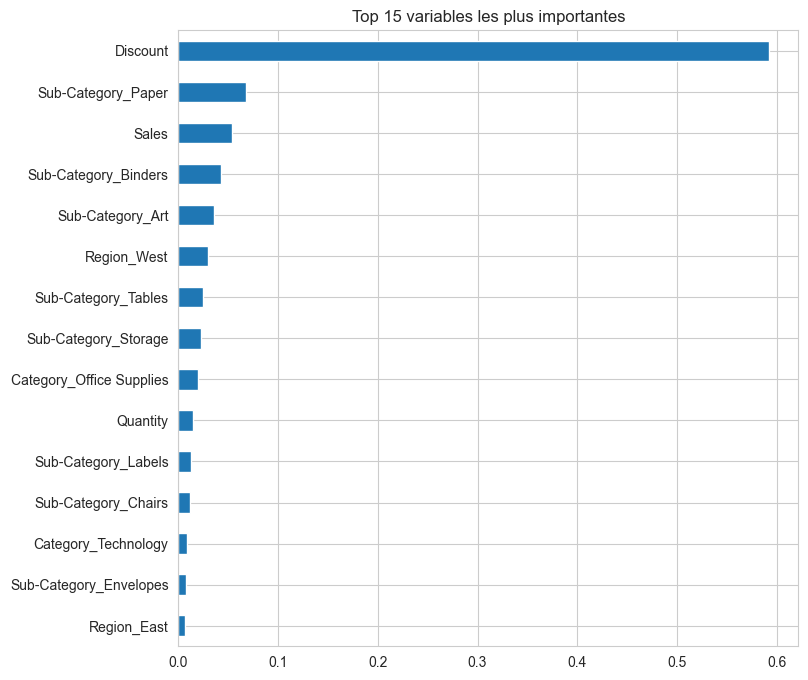

In [60]:
plt.figure(figsize=(8,8))
importances.head(15).plot(kind='barh')
plt.title("Top 15 variables les plus importantes")
plt.gca().invert_yaxis()
plt.show()

In [61]:
import joblib

In [62]:
joblib.dump(rf,'model_rf.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X_train.columns.tolist(),'model_columns.pkl')

['model_columns.pkl']

In [63]:
snapshot_date=df['Order Date'].max()+pd.Timedelta(days=1)

In [64]:
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum'),
    Customer_Name=('Customer Name', 'first')
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Customer_Name
0,AA-10315,185,5,5563.560,Alex Avila
1,AA-10375,20,9,1056.390,Allen Armold
2,AA-10480,260,4,1790.512,Andrew Allen
3,AA-10645,56,6,5086.935,Anna Andreadi
4,AB-10015,416,3,886.156,Aaron Bergman


In [65]:
rfm['R_score']=pd.qcut(rfm['Recency'],4,labels=[4,3,2,1])


In [66]:
rfm['F_score']=pd.qcut(rfm['Frequency'].rank(method='first'),4,labels=[1,2,3,4])

In [67]:
rfm['M_score']=pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4])

In [68]:
rfm['RFM_score']=rfm['R_score'].astype(str)+rfm['F_score'].astype(str)+rfm['M_score'].astype(str)

In [69]:
def segment_customer(row):
    score=int(row['R_score'])+int(row['F_score'])+int(row['M_score'])
    if score>=10:
        return 'Champions'
    elif score>=8:
        return 'Loyal Customers'
    elif score>=6:
        return'Potential Loyalists'
    elif score>=4:
        return'At Risk'
    else:
        return'Lost Customers'
rfm['Segment']=rfm.apply(segment_customer,axis=1)

In [70]:
print(rfm['Segment'].value_counts(dropna=False))

Segment
Loyal Customers        222
Champions              193
Potential Loyalists    182
At Risk                141
Lost Customers          55
Name: count, dtype: int64


In [71]:
print(
    rfm[rfm['Segment'].isna() | (rfm['Segment'] == '')]
    [['Customer ID', 'Customer_Name', 'R_score', 'F_score', 'M_score', 'Segment']]
    .head(20)
)

Empty DataFrame
Columns: [Customer ID, Customer_Name, R_score, F_score, M_score, Segment]
Index: []


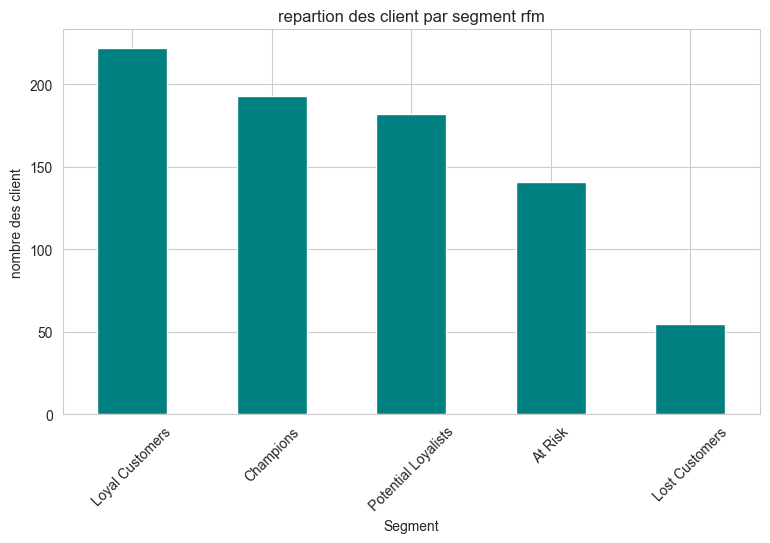

In [72]:
plt.figure(figsize=(9,5))
rfm['Segment'].value_counts().plot(kind='bar',color='teal')
plt.title("repartion des client par segment rfm")
plt.ylabel("nombre des client")
plt.xticks(rotation=45)
plt.show()




In [73]:
import os


In [74]:
os.makedirs('powerbi_exports',exist_ok=True)

In [75]:
df.to_csv('powerbi_exports/superstore_clean.csv', index=False, decimal='.', sep=',')

In [76]:
rfm.to_csv('powerbi_exports/customer_rfm.csv',index=False)

In [77]:
product_summary=df.groupby(['Product Name','Category','Sub-Category']).agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Total_Quantity=('Quantity','sum')
).reset_index()

In [78]:
product_summary['Profit_Margin']=product_summary['Total_Profit']/product_summary['Total_Sales']
product_summary.to_csv('powerbi_exports/product_summary.csv',index=False)

In [79]:
monthly_summary=df.groupby(df['Order Date'].dt.to_period('M').astype(str)).agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Order_count=('Order ID','nunique')
).reset_index().rename(columns={'Order Date':'Month'})


In [80]:
monthly_summary.to_csv('powerbi_exports/monthly_summary.csv',index=False)

In [81]:
print("4fichier exportees dans le dossier 'powerbi_exports'")

4fichier exportees dans le dossier 'powerbi_exports'


In [82]:
import os

In [83]:
print(os.listdir('powerbi_exports'))

['customer_rfm.csv', 'monthly_summary.csv', 'product_summary.csv', 'superstore_clean.csv']


In [84]:
print(rfm[['R_score', 'F_score', 'M_score']].isna().sum())

R_score    0
F_score    0
M_score    0
dtype: int64


In [86]:
print(rfm[rfm['R_score'].isna()][
    ['Customer ID', 'Customer_Name', 'R_score', 'F_score', 'M_score']
].head())

Empty DataFrame
Columns: [Customer ID, Customer_Name, R_score, F_score, M_score]
Index: []


In [87]:
import joblib

In [88]:

joblib.dump(rf, 'model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']